In [1]:
# ============================================
# STUDENT DROPOUT PREDICTION - EDA & VISUALIZATION
# Author: IT24103869 - Thennakoon T.M.S.D
# Date: February 2026
# ============================================

# Cell 1: Mount Google Drive and Install Libraries
from google.colab import drive
drive.mount('/content/drive')

# Install required libraries
!pip install pandas numpy matplotlib seaborn plotly scikit-learn wordcloud openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import LabelEncoder
from scipy import stats
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# Set style and display options
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("="*60)
print("📊 STUDENT DROPOUT PREDICTION - EDA ANALYSIS")
print("="*60)
print("✅ All libraries imported successfully!")

Mounted at /content/drive
📊 STUDENT DROPOUT PREDICTION - EDA ANALYSIS
✅ All libraries imported successfully!


In [2]:
# Cell 2: Upload Dataset
print("\n" + "="*60)
print("📤 LOADING DATASET")
print("="*60)

# Try to load from Google Drive first
drive_path = '/content/drive/MyDrive/student-dropout-project/csv_exports/student_dropout_preprocessed_full.csv'

if os.path.exists(drive_path):
    df = pd.read_csv(drive_path)
    print(f"✅ Loaded from Google Drive: {drive_path}")
else:
    # If not in Drive, ask to upload
    from google.colab import files
    print("📤 Please upload the preprocessed CSV file:")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename)
    print(f"✅ Loaded: {filename}")

print(f"\n📊 Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 Columns:\n{df.columns.tolist()}")

# Display first few rows
print("\n👀 First 5 rows:")
df.head()


📤 LOADING DATASET
📤 Please upload the preprocessed CSV file:


Saving student_dropout_preprocessed_full.csv to student_dropout_preprocessed_full.csv
✅ Loaded: student_dropout_preprocessed_full.csv

📊 Dataset shape: 4424 rows × 47 columns

📋 Columns:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,Target,success_rate_sem1,success_rate_sem2,grade_improvement,total_workload,failure_rate_sem1,failure_rate_sem2,credits_utilization_sem1,credits_utilization_sem2,age_group,family_support,parents_education,academic_performance_score,risk_score
0,1,8,5,2.0,1,1,1,13.0,10.0,6.0,10,1.0,0,0,1.0,1,0,20.0,0.0,0.0,0,0,0.0,0.000000,0,0,0.0,0,0,0.000000,0,10.8,1.4,Dropout,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,18-20,2.5,11.5,0.000000,3.0
1,1,6,1,11.0,1,1,1,1.0,3.0,4.0,4,1.0,0,0,0.0,1,0,19.0,0.0,0.0,6,6,6.0,14.000000,0,0,6.0,6,6,13.666667,0,13.9,-0.3,Graduate,1.000000,1.000000,-0.333333,12.0,0.000000,0.000000,0.0,0.0,18-20,1.5,2.0,13.833333,2.0
2,1,1,5,5.0,1,1,1,22.0,27.0,10.0,10,1.0,0,0,0.0,1,0,19.0,0.0,0.0,6,0,0.0,0.000000,0,0,6.0,0,0,0.000000,0,10.8,1.4,Dropout,0.000000,0.000000,0.000000,12.0,1.000000,1.000000,0.0,0.0,18-20,1.5,24.5,0.000000,5.0
3,1,8,2,15.0,1,1,1,23.0,27.0,6.0,4,1.0,0,0,1.0,0,0,20.0,0.0,0.0,6,8,6.0,13.428571,0,0,6.0,10,5,12.400000,0,9.4,-0.8,Graduate,1.000000,0.833333,-1.028571,12.0,0.000000,0.166667,0.0,0.0,18-20,2.5,25.0,11.880952,0.5
4,2,12,1,3.0,0,1,1,22.0,28.0,10.0,10,0.0,0,0,1.0,0,0,45.0,0.0,0.0,6,9,5.0,12.333333,0,0,6.0,6,6,13.000000,0,13.9,-0.3,Graduate,0.833333,1.000000,0.666667,12.0,0.166667,0.000000,0.0,0.0,30+,2.0,25.0,11.638889,1.0


In [3]:
# Cell 3: Dataset Overview
print("\n" + "="*60)
print("📋 DATASET OVERVIEW")
print("="*60)

# 3.1 Data Types
print("\n📌 Data Types:")
dtype_df = pd.DataFrame(df.dtypes, columns=['Data Type'])
print(dtype_df)

# 3.2 Missing Values Check
print("\n📌 Missing Values Check:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': round(missing_pct, 2)
})
missing_cols = missing_df[missing_df['Missing_Count'] > 0]
if len(missing_cols) > 0:
    print(missing_cols)
else:
    print("✅ No missing values found!")

# 3.3 Basic Statistics
print("\n📊 Statistical Summary:")
df.describe()


📋 DATASET OVERVIEW

📌 Data Types:
                                               Data Type
Marital status                                     int64
Application mode                                   int64
Application order                                  int64
Course                                           float64
Daytime/evening attendance                         int64
Previous qualification                             int64
Nacionality                                        int64
Mother's qualification                           float64
Father's qualification                           float64
Mother's occupation                              float64
Father's occupation                                int64
Displaced                                        float64
Educational special needs                          int64
Debtor                                             int64
Tuition fees up to date                          float64
Gender                                             in

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,success_rate_sem1,success_rate_sem2,grade_improvement,total_workload,failure_rate_sem1,failure_rate_sem2,credits_utilization_sem1,credits_utilization_sem2,family_support,parents_education,academic_performance_score,risk_score
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.897604,0.890823,2.531420,1.254521,12.317812,16.455018,7.315099,7.819168,0.548599,0.011528,0.113698,0.880651,0.351718,0.248418,23.266275,0.024864,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232369,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.697885,0.660364,-0.410616,12.503165,0.261422,0.298946,0.064339,0.052677,2.538201,14.386076,8.733118,1.721554
std,0.605747,5.298964,1.313793,4.330476,0.311897,3.963707,1.748447,9.023660,11.041646,3.997364,4.856692,0.497689,0.106760,0.317480,0.324235,0.477560,0.432144,7.587195,0.155729,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195875,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,0.365247,0.382967,2.890376,4.608674,0.340065,0.363258,0.184284,0.162875,1.128680,8.770784,4.904264,1.941883
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,0.000000,0.000000,-16.142857,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,0.500000,0.400000,-0.600000,10.000000,0.000000,0.000000,0.000000,0.000000,2.000000,7.000000,5.535119,0.000000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,8.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.833333,0.833333,0.000000,12.000000,0.142857,0.153846,0.000000,0.000000,2.500000,14.500000,10.400000,1.000000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,10.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.000000,1.000000,0.45


🎯 TARGET VARIABLE ANALYSIS

📊 Target Distribution:
   Graduate: 2209 (49.9%)
   Dropout: 1421 (32.1%)
   Enrolled: 794 (17.9%)


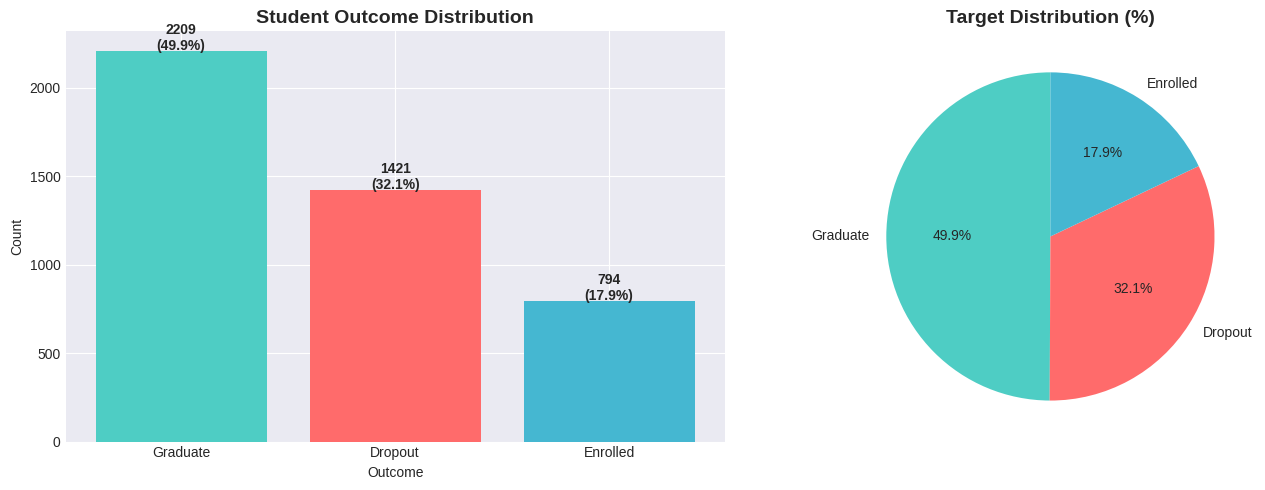

✅ Saved: target_distribution.png


In [4]:
# Cell 4: Target Distribution Analysis
print("\n" + "="*60)
print("🎯 TARGET VARIABLE ANALYSIS")
print("="*60)

# 4.1 Target Distribution
target_counts = df['Target'].value_counts()
target_percentages = df['Target'].value_counts(normalize=True) * 100

print("\n📊 Target Distribution:")
for outcome, count in target_counts.items():
    print(f"   {outcome}: {count} ({target_percentages[outcome]:.1f}%)")

# 4.2 Color mapping for consistent visualization
colors = {
    'Dropout': '#FF6B6B',
    'Graduate': '#4ECDC4',
    'Enrolled': '#45B7D1'
}

# 4.3 Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
bars = axes[0].bar(target_counts.index, target_counts.values,
                   color=[colors[x] for x in target_counts.index])
axes[0].set_title('Student Outcome Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Count')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{height}\n({height/len(df)*100:.1f}%)',
                ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=[colors[x] for x in target_counts.index], startangle=90)
axes[1].set_title('Target Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: target_distribution.png")


📈 NUMERICAL FEATURES DISTRIBUTION

📊 Analyzing top 12 important features...


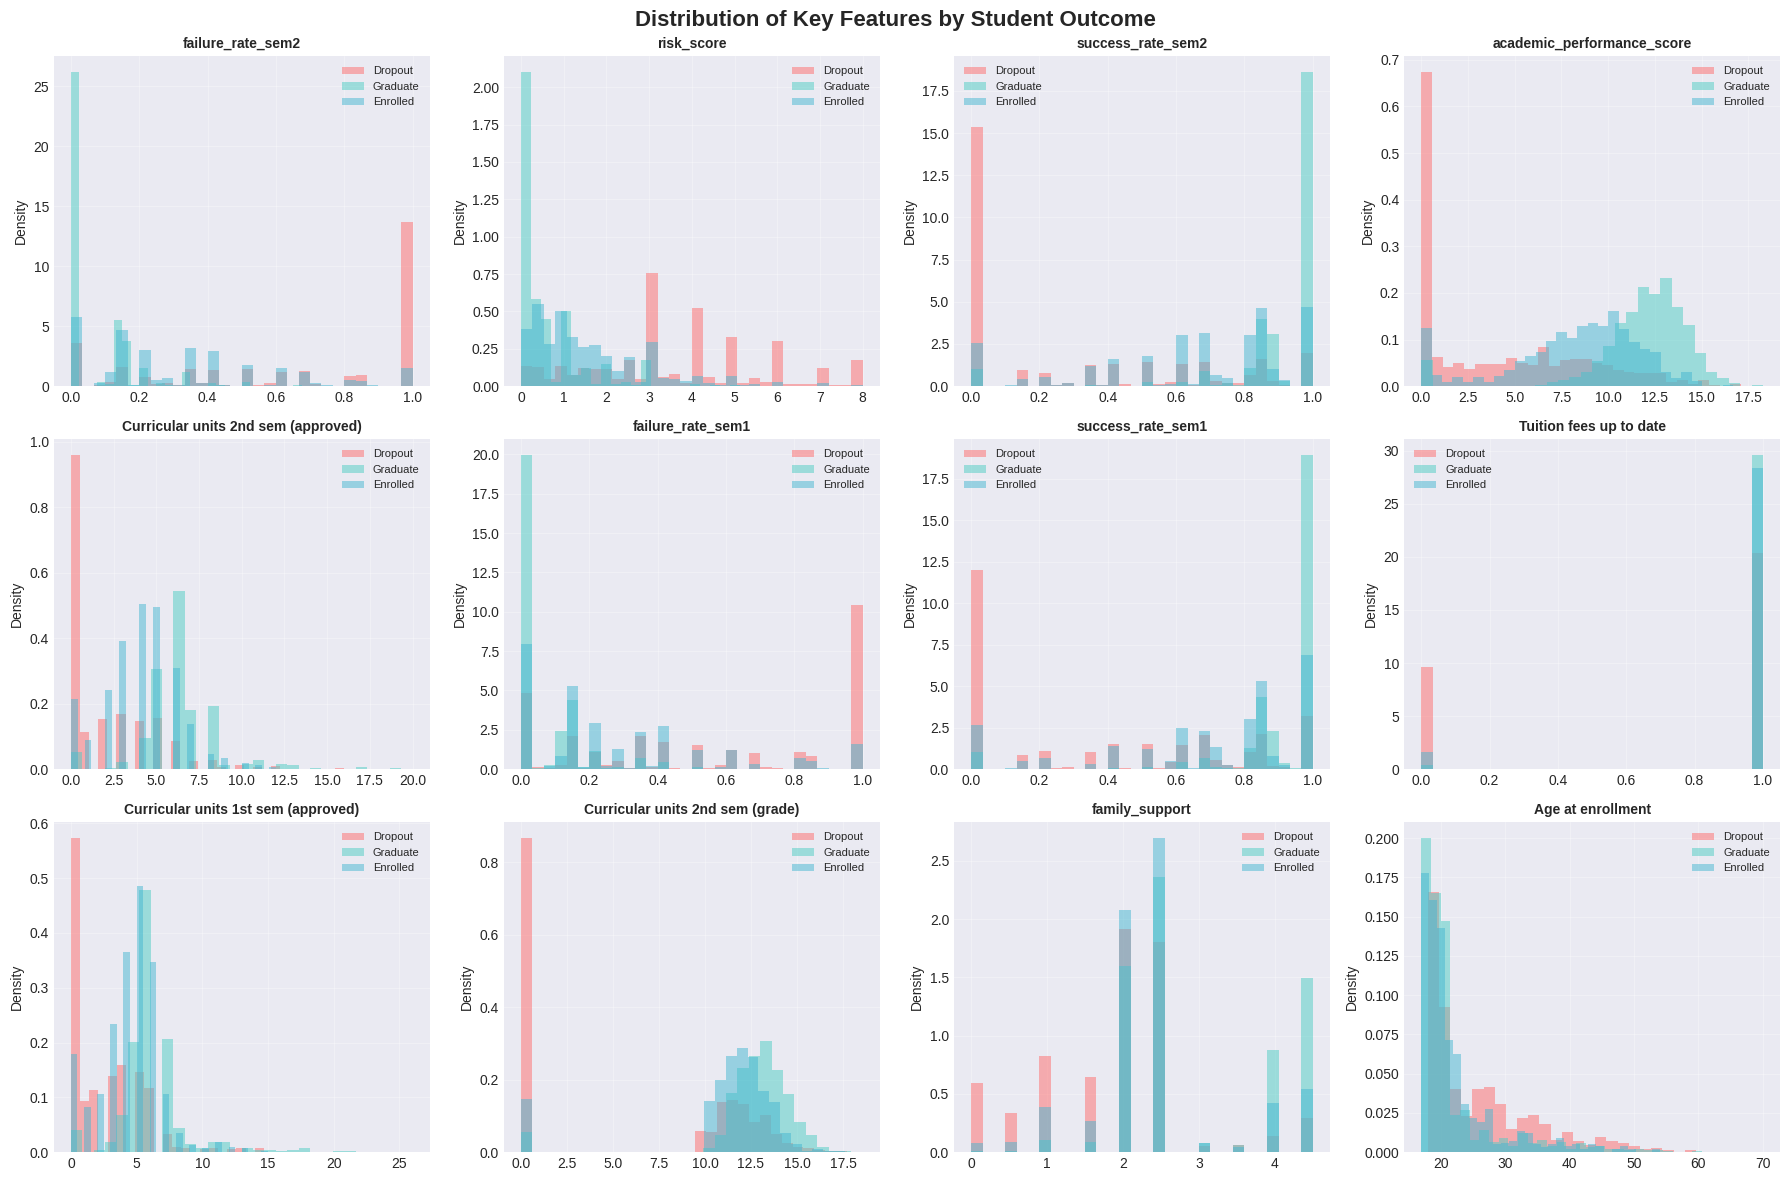

✅ Saved: feature_distributions.png


In [5]:
# Cell 5: Numerical Features Distribution
print("\n" + "="*60)
print("📈 NUMERICAL FEATURES DISTRIBUTION")
print("="*60)

# Select numerical columns (exclude Target if it's categorical)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# SHAP-identified important features
shap_important_features = [
    'failure_rate_sem2', 'risk_score', 'success_rate_sem2',
    'academic_performance_score', 'Curricular units 2nd sem (approved)',
    'failure_rate_sem1', 'success_rate_sem1', 'Tuition fees up to date',
    'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (grade)',
    'family_support', 'Age at enrollment', 'Unemployment rate',
    'Curricular units 1st sem (grade)', 'Inflation rate'
]

# Filter to only features that exist in dataframe
features_to_plot = [f for f in shap_important_features if f in df.columns][:12]

print(f"\n📊 Analyzing top {len(features_to_plot)} important features...")

# Create distribution plots
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot[:12]):
    ax = axes[idx]

    # Plot histogram with KDE for each outcome
    for outcome in df['Target'].unique():
        subset = df[df['Target'] == outcome]
        ax.hist(subset[feature], alpha=0.5, label=outcome, bins=30, density=True,
                color=colors.get(outcome, '#808080'))

    ax.set_title(f'{feature}', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(len(features_to_plot), 12):
    axes[idx].set_visible(False)

plt.suptitle('Distribution of Key Features by Student Outcome', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_distributions.png")


📦 BOX PLOT ANALYSIS - OUTLIER DETECTION


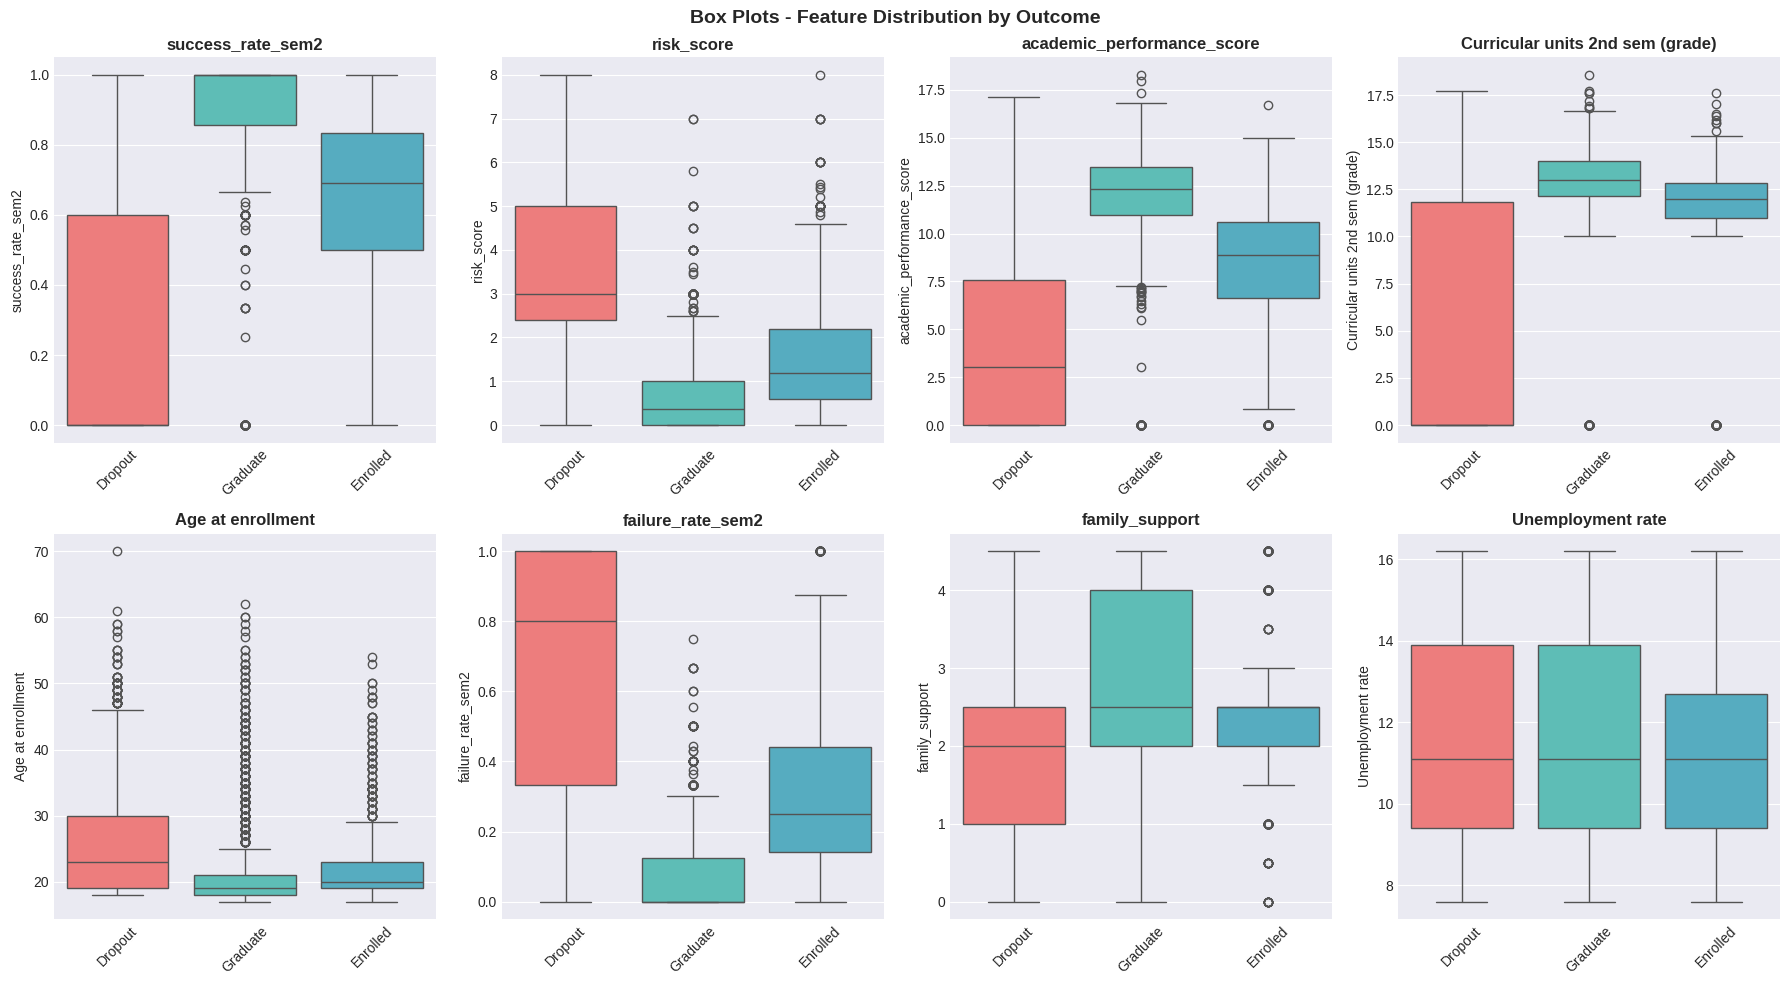

✅ Saved: box_plots.png


In [6]:
# Cell 6: Box Plot Analysis
print("\n" + "="*60)
print("📦 BOX PLOT ANALYSIS - OUTLIER DETECTION")
print("="*60)

# Select features for box plots
box_features = ['success_rate_sem2', 'risk_score', 'academic_performance_score',
                'Curricular units 2nd sem (grade)', 'Age at enrollment',
                'failure_rate_sem2', 'family_support', 'Unemployment rate']

box_features = [f for f in box_features if f in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(box_features):
    ax = axes[idx]
    sns.boxplot(data=df, x='Target', y=feature, ax=ax,
                palette=[colors[x] for x in df['Target'].unique()])
    ax.set_title(f'{feature}', fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

# Hide empty subplots
for idx in range(len(box_features), 8):
    axes[idx].set_visible(False)

plt.suptitle('Box Plots - Feature Distribution by Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('box_plots.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: box_plots.png")


📊 CATEGORICAL FEATURES ANALYSIS

📌 Categorical features: ['age_group']


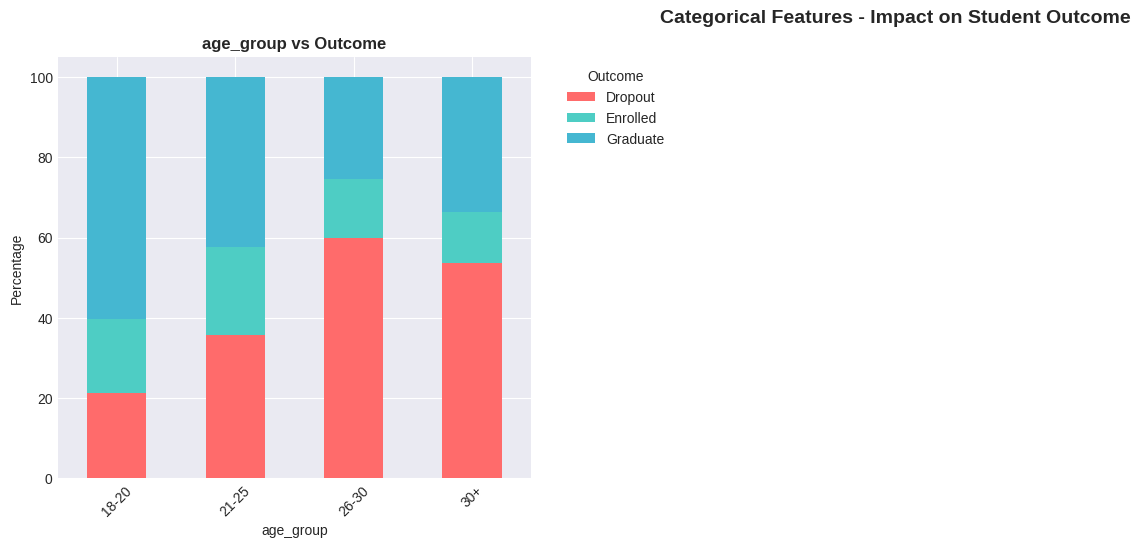

✅ Saved: categorical_analysis.png


In [9]:
# Cell 7: Categorical Features Analysis
print("\n" + "="*60)
print("📊 CATEGORICAL FEATURES ANALYSIS")
print("="*60)

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
categorical_cols = [col for col in categorical_cols if col != 'Target']

print(f"\n📌 Categorical features: {categorical_cols}")

# Plot categorical features
if len(categorical_cols) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, feature in enumerate(categorical_cols[:6]):
        ax = axes[idx]

        # Create crosstab
        ct = pd.crosstab(df[feature], df['Target'], normalize='index') * 100

        # Plot stacked bar chart
        ct.plot(kind='bar', stacked=True, ax=ax,
                color=[colors['Dropout'], colors['Graduate'], colors['Enrolled']])
        ax.set_title(f'{feature} vs Outcome', fontweight='bold')
        ax.set_ylabel('Percentage')
        ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1))
        ax.tick_params(axis='x', rotation=45)

    # Hide empty subplots
    for idx in range(len(categorical_cols), 6):
        axes[idx].set_visible(False)

    plt.suptitle('Categorical Features - Impact on Student Outcome', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('categorical_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: categorical_analysis.png")
else:
    print("⚠️ No categorical features found for analysis")


🔗 CORRELATION ANALYSIS
✅ Target encoding: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


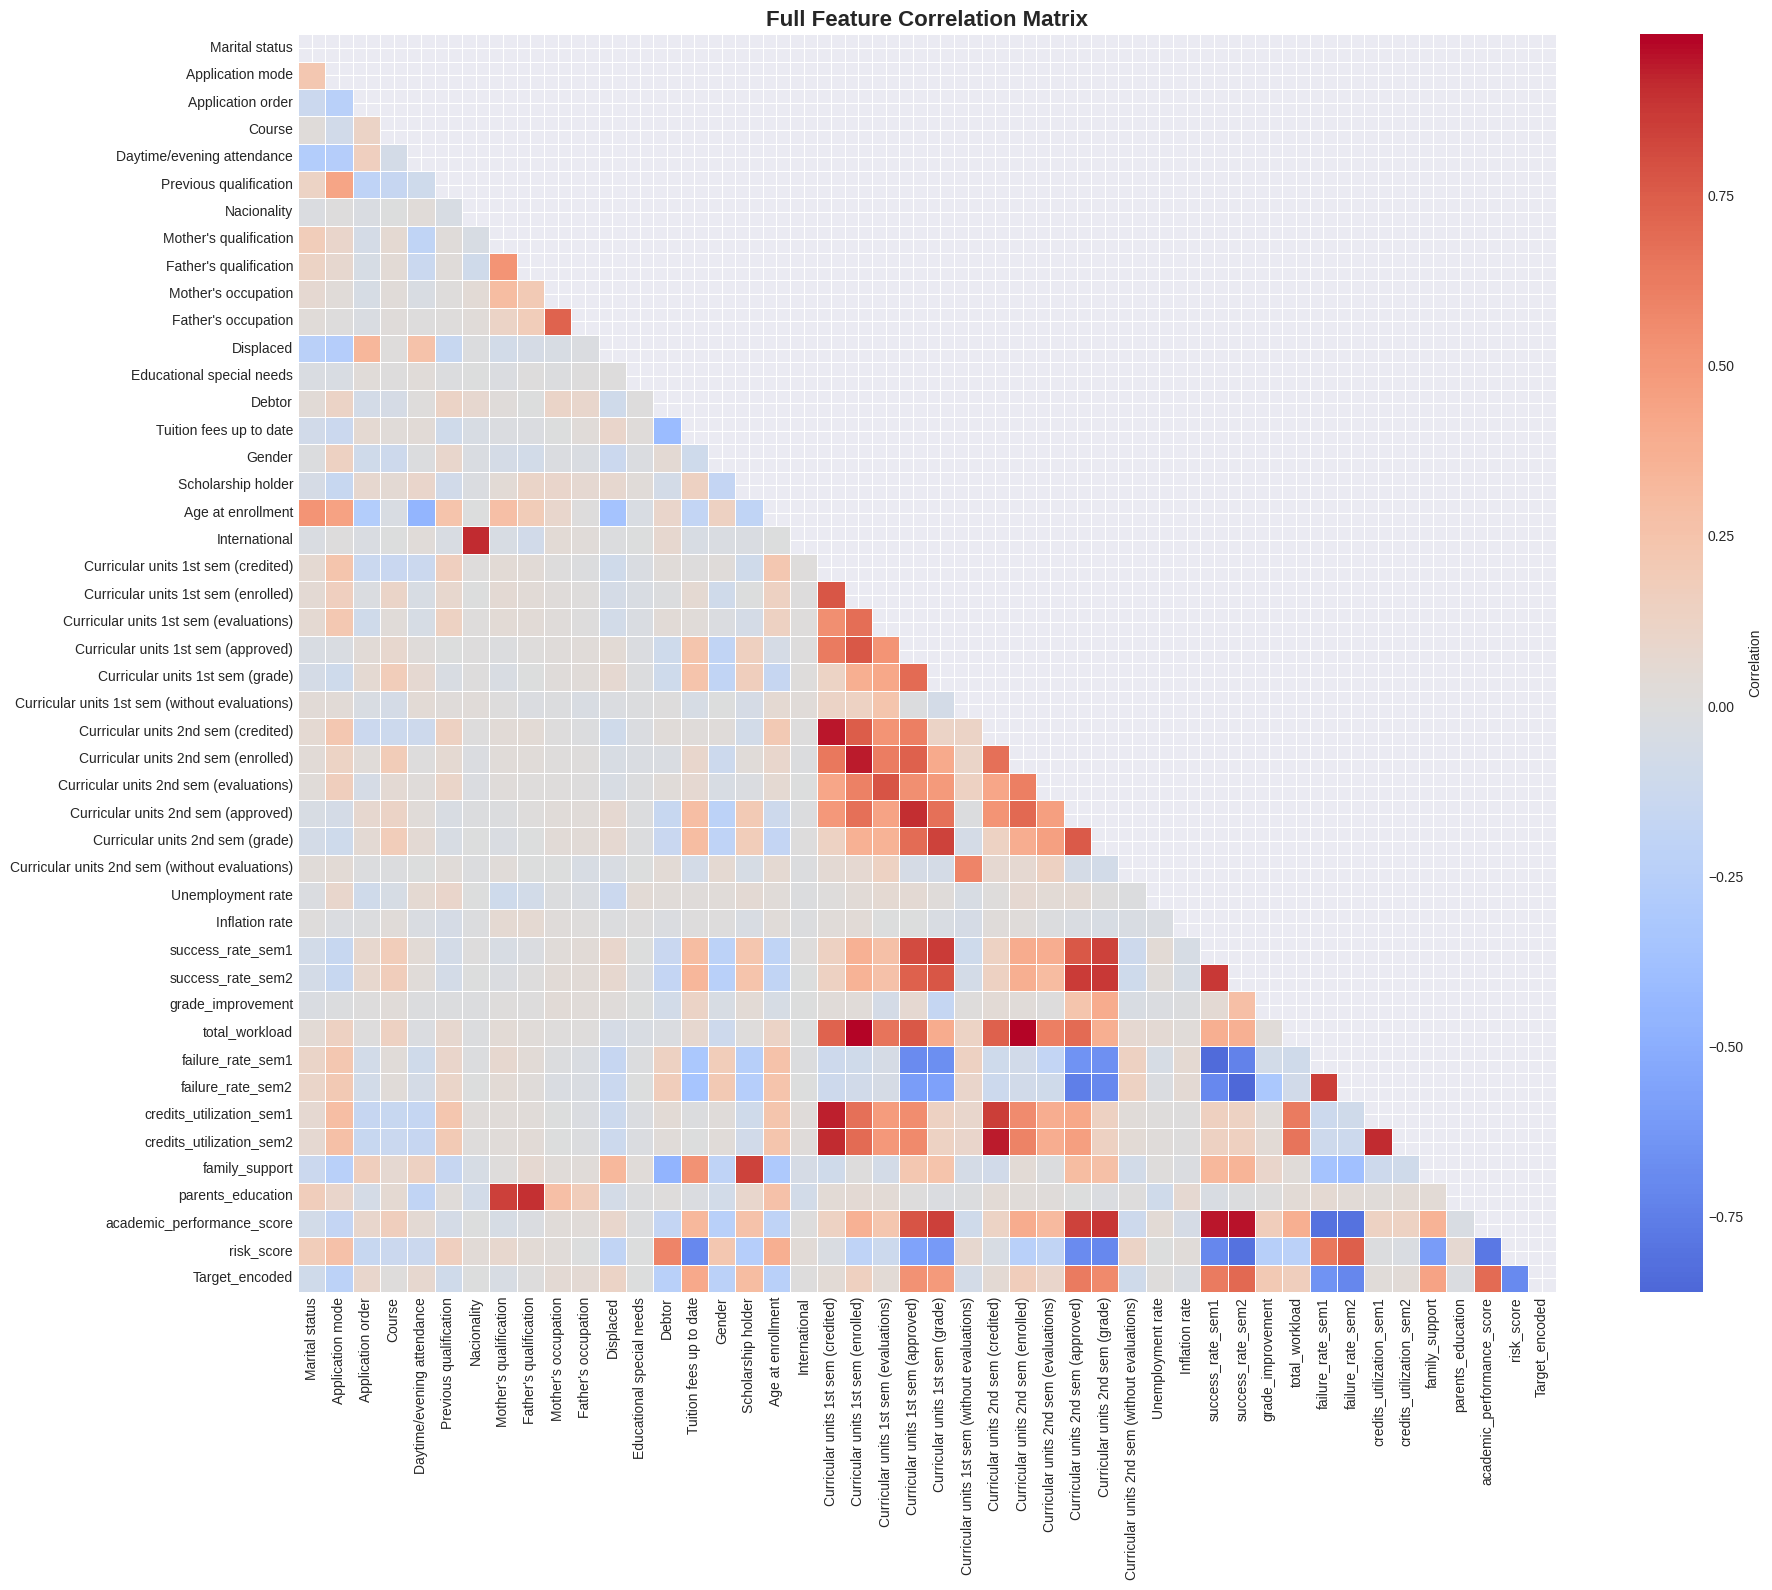

✅ Saved: correlation_heatmap_full.png

📊 Top 15 Features Correlated with Dropout Risk:
success_rate_sem2                      0.699168
academic_performance_score             0.696410
success_rate_sem1                      0.626945
Curricular units 2nd sem (approved)    0.624157
Curricular units 2nd sem (grade)       0.566827
Curricular units 1st sem (approved)    0.529123
Curricular units 1st sem (grade)       0.485207
family_support                         0.438721
Tuition fees up to date                0.409827
Scholarship holder                     0.297595
grade_improvement                      0.208778
Curricular units 2nd sem (enrolled)    0.175948
total_workload                         0.167817
Curricular units 1st sem (enrolled)    0.155974
Displaced                              0.114411


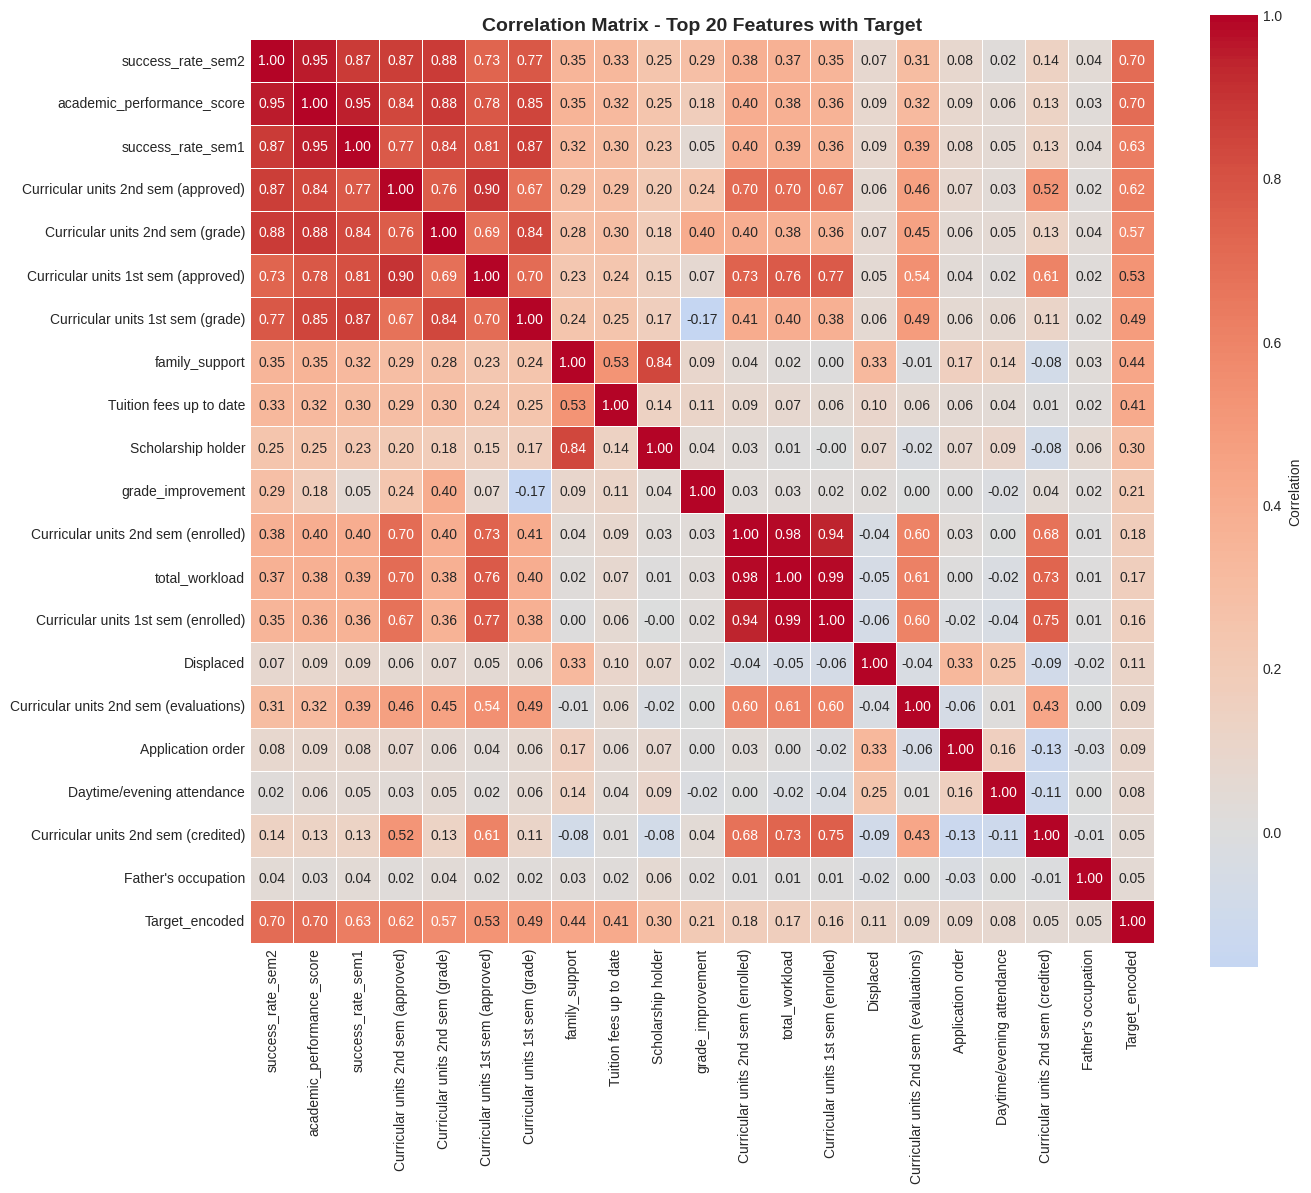

✅ Saved: correlation_heatmap_top20.png


In [10]:
# Cell 8: Correlation Analysis
print("\n" + "="*60)
print("🔗 CORRELATION ANALYSIS")
print("="*60)

# Encode target for correlation
le = LabelEncoder()
df_corr = df.copy()
df_corr['Target_encoded'] = le.fit_transform(df_corr['Target'])
print(f"✅ Target encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Select numerical columns for correlation
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns
correlation_matrix = df_corr[numeric_cols].corr()

# 8.1 Full Correlation Heatmap
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Full Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap_full.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: correlation_heatmap_full.png")

# 8.2 Top Correlations with Target
target_corr = correlation_matrix['Target_encoded'].drop('Target_encoded').sort_values(ascending=False)
print("\n📊 Top 15 Features Correlated with Dropout Risk:")
print(target_corr.head(15).to_string())

# 8.3 Correlation Heatmap - Top Features
top_corr_features = target_corr.head(20).index.tolist()
top_corr_matrix = df_corr[top_corr_features + ['Target_encoded']].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(top_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix - Top 20 Features with Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap_top20.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: correlation_heatmap_top20.png")


🌟 SHAP FEATURE IMPORTANCE ANALYSIS

✅ SHAP Feature Importance Loaded
                            Feature  Dropout_Impact  Graduate_Impact  Enrolled_Impact
                  failure_rate_sem2            0.18             0.15             0.16
                         risk_score            0.15             0.14             0.13
                  success_rate_sem2            0.12             0.11             0.10
         academic_performance_score            0.10             0.09             0.08
Curricular units 2nd sem (approved)            0.11             0.10             0.09
                  failure_rate_sem1            0.10             0.09             0.08
                  success_rate_sem1            0.09             0.08             0.07
            Tuition fees up to date            0.08             0.07             0.06
Curricular units 1st sem (approved)            0.07             0.06             0.05
   Curricular units 2nd sem (grade)            0.06             0.05  

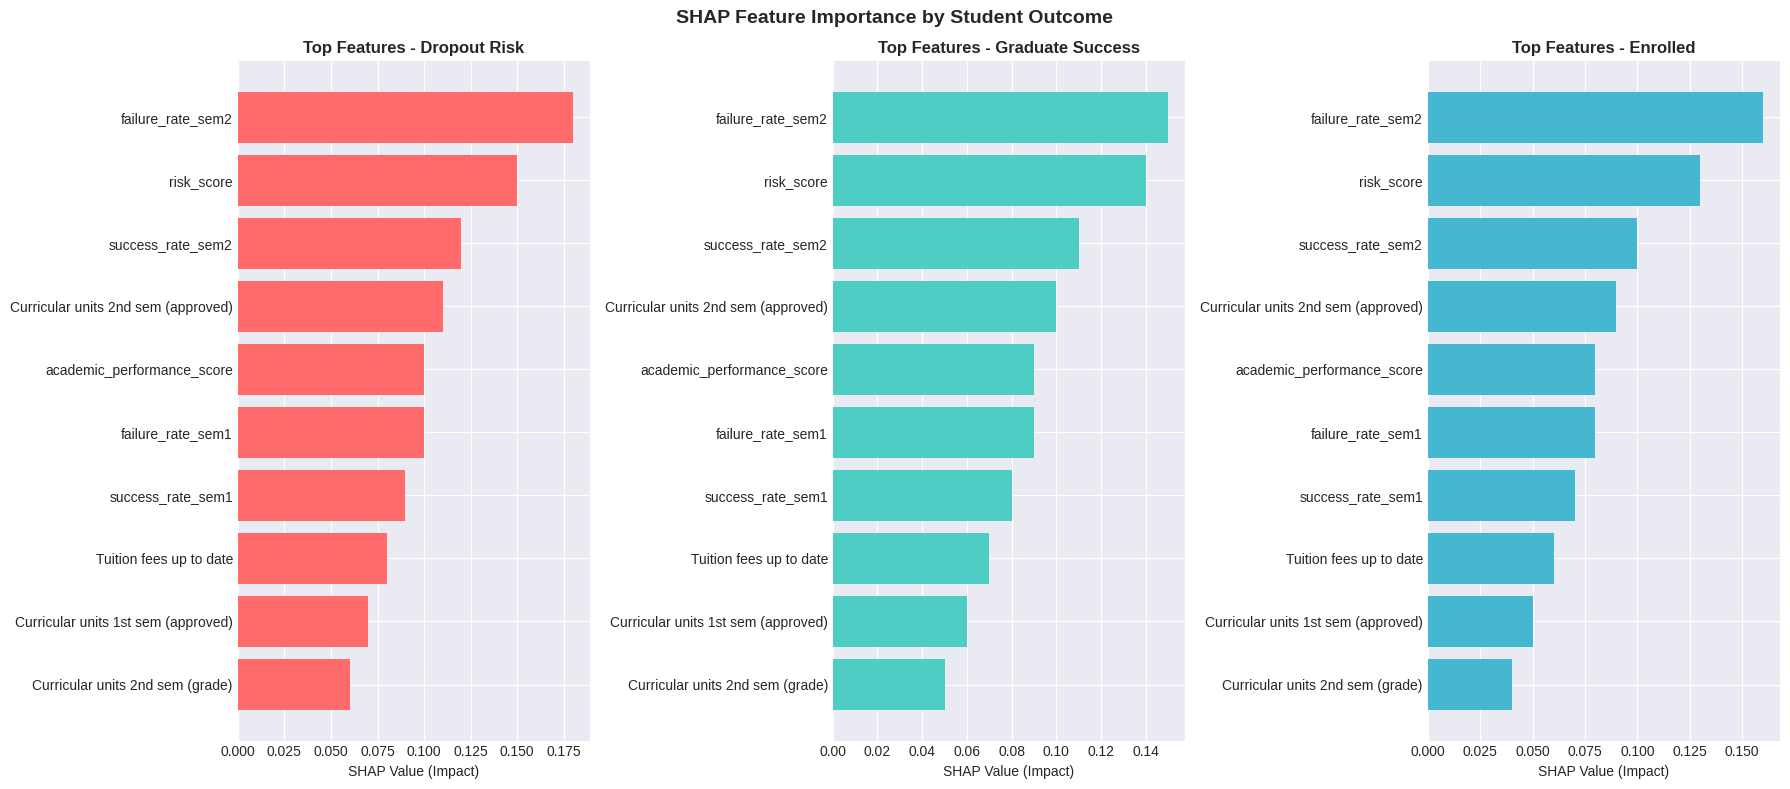

✅ Saved: shap_feature_importance_by_class.png

📊 SHAP vs Correlation - Top 10 Features:
                            Feature  SHAP_Impact  Correlation
                  failure_rate_sem2         0.18    -0.713242
                         risk_score         0.15    -0.688158
                  success_rate_sem2         0.12     0.699168
         academic_performance_score         0.10     0.696410
Curricular units 2nd sem (approved)         0.11     0.624157
                  failure_rate_sem1         0.10    -0.647890
                  success_rate_sem1         0.09     0.626945
            Tuition fees up to date         0.08     0.409827
Curricular units 1st sem (approved)         0.07     0.529123
   Curricular units 2nd sem (grade)         0.06     0.566827


In [11]:
# Cell 9: SHAP Feature Importance Analysis
print("\n" + "="*60)
print("🌟 SHAP FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# SHAP data from model training
shap_data = {
    'Feature': [
        'failure_rate_sem2', 'risk_score', 'success_rate_sem2',
        'academic_performance_score', 'Curricular units 2nd sem (approved)',
        'failure_rate_sem1', 'success_rate_sem1', 'Tuition fees up to date',
        'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (grade)',
        'family_support', 'Course', 'Age at enrollment', 'Unemployment rate',
        'Curricular units 1st sem (grade)', 'Inflation rate', "Mother's occupation",
        'Curricular units 2nd sem (evaluations)', 'parents_education', 'grade_improvement'
    ],
    'Dropout_Impact': [
        0.18, 0.15, 0.12, 0.10, 0.11, 0.10, 0.09, 0.08, 0.07, 0.06,
        0.05, 0.04, 0.03, 0.02, 0.01, 0.01, 0.00, 0.00, 0.00, 0.00
    ],
    'Graduate_Impact': [
        0.15, 0.14, 0.11, 0.09, 0.10, 0.09, 0.08, 0.07, 0.06, 0.05,
        0.04, 0.03, 0.02, 0.01, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00
    ],
    'Enrolled_Impact': [
        0.16, 0.13, 0.10, 0.08, 0.09, 0.08, 0.07, 0.06, 0.05, 0.04,
        0.03, 0.02, 0.01, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00
    ]
}

shap_df = pd.DataFrame(shap_data)
print("\n✅ SHAP Feature Importance Loaded")
print(shap_df.head(10).to_string(index=False))

# 9.1 SHAP Visualization by Class
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Dropout (Class 0)
top_dropout = shap_df.nlargest(10, 'Dropout_Impact')
axes[0].barh(range(len(top_dropout)), top_dropout['Dropout_Impact'].values,
             color='#FF6B6B')
axes[0].set_yticks(range(len(top_dropout)))
axes[0].set_yticklabels(top_dropout['Feature'].values)
axes[0].set_xlabel('SHAP Value (Impact)')
axes[0].set_title('Top Features - Dropout Risk', fontweight='bold')
axes[0].invert_yaxis()

# Graduate (Class 2)
top_graduate = shap_df.nlargest(10, 'Graduate_Impact')
axes[1].barh(range(len(top_graduate)), top_graduate['Graduate_Impact'].values,
             color='#4ECDC4')
axes[1].set_yticks(range(len(top_graduate)))
axes[1].set_yticklabels(top_graduate['Feature'].values)
axes[1].set_xlabel('SHAP Value (Impact)')
axes[1].set_title('Top Features - Graduate Success', fontweight='bold')
axes[1].invert_yaxis()

# Enrolled (Class 1)
top_enrolled = shap_df.nlargest(10, 'Enrolled_Impact')
axes[2].barh(range(len(top_enrolled)), top_enrolled['Enrolled_Impact'].values,
             color='#45B7D1')
axes[2].set_yticks(range(len(top_enrolled)))
axes[2].set_yticklabels(top_enrolled['Feature'].values)
axes[2].set_xlabel('SHAP Value (Impact)')
axes[2].set_title('Top Features - Enrolled', fontweight='bold')
axes[2].invert_yaxis()

plt.suptitle('SHAP Feature Importance by Student Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_feature_importance_by_class.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_feature_importance_by_class.png")

# 9.2 SHAP vs Correlation Comparison
print("\n📊 SHAP vs Correlation - Top 10 Features:")
comparison = pd.DataFrame({
    'Feature': shap_df['Feature'].head(10),
    'SHAP_Impact': shap_df['Dropout_Impact'].head(10),
    'Correlation': [target_corr.get(f, 0) for f in shap_df['Feature'].head(10)]
})
print(comparison.to_string(index=False))


⚠️ RISK SCORE ANALYSIS

📊 Risk Score Statistics:
          mean  median   std  min  max
Target                                
Dropout   3.61    3.00  1.99  0.0  8.0
Enrolled  1.56    1.20  1.31  0.0  8.0
Graduate  0.56    0.38  0.86  0.0  7.0


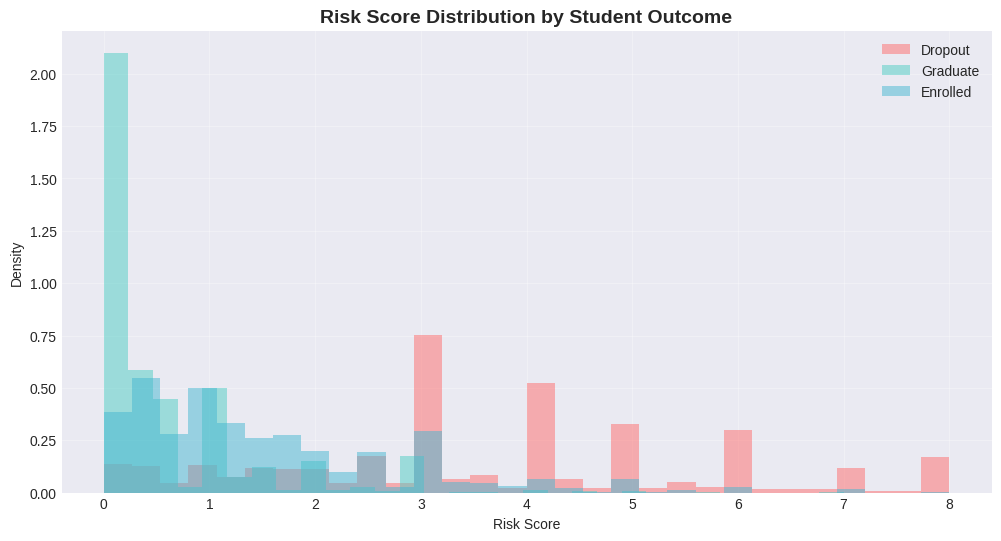

✅ Saved: risk_score_distribution.png

🎯 Proposed Risk Thresholds:
   Low Risk: < 0.38
   Medium Risk: 0.38 - 2.00
   High Risk: > 2.00

✅ Threshold Validation - Outcome Distribution by Risk Category:
Target         Dropout  Enrolled  Graduate
risk_category                             
Low                4.2       7.0      88.8
Medium            17.3      31.9      50.8
High              76.1      14.5       9.4


In [12]:
# Cell 10: Risk Score Analysis
print("\n" + "="*60)
print("⚠️ RISK SCORE ANALYSIS")
print("="*60)

if 'risk_score' in df.columns:
    # 10.1 Risk Score Statistics
    print("\n📊 Risk Score Statistics:")
    risk_stats = df.groupby('Target')['risk_score'].agg(['mean', 'median', 'std', 'min', 'max'])
    print(risk_stats.round(2))

    # 10.2 Risk Score Distribution
    plt.figure(figsize=(12, 6))
    for outcome in df['Target'].unique():
        subset = df[df['Target'] == outcome]
        plt.hist(subset['risk_score'], alpha=0.5, label=outcome, bins=30,
                 density=True, color=colors.get(outcome, '#808080'))

    plt.xlabel('Risk Score')
    plt.ylabel('Density')
    plt.title('Risk Score Distribution by Student Outcome', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('risk_score_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: risk_score_distribution.png")

    # 10.3 Optimal Risk Thresholds
    low_threshold = df['risk_score'].quantile(0.33)
    high_threshold = df['risk_score'].quantile(0.66)

    print(f"\n🎯 Proposed Risk Thresholds:")
    print(f"   Low Risk: < {low_threshold:.2f}")
    print(f"   Medium Risk: {low_threshold:.2f} - {high_threshold:.2f}")
    print(f"   High Risk: > {high_threshold:.2f}")

    # 10.4 Validate Thresholds
    df['risk_category'] = pd.cut(df['risk_score'],
                                  bins=[-np.inf, low_threshold, high_threshold, np.inf],
                                  labels=['Low', 'Medium', 'High'])

    validation = pd.crosstab(df['risk_category'], df['Target'], normalize='index') * 100
    print("\n✅ Threshold Validation - Outcome Distribution by Risk Category:")
    print(validation.round(1))


📊 FEATURE IMPACT MATRIX


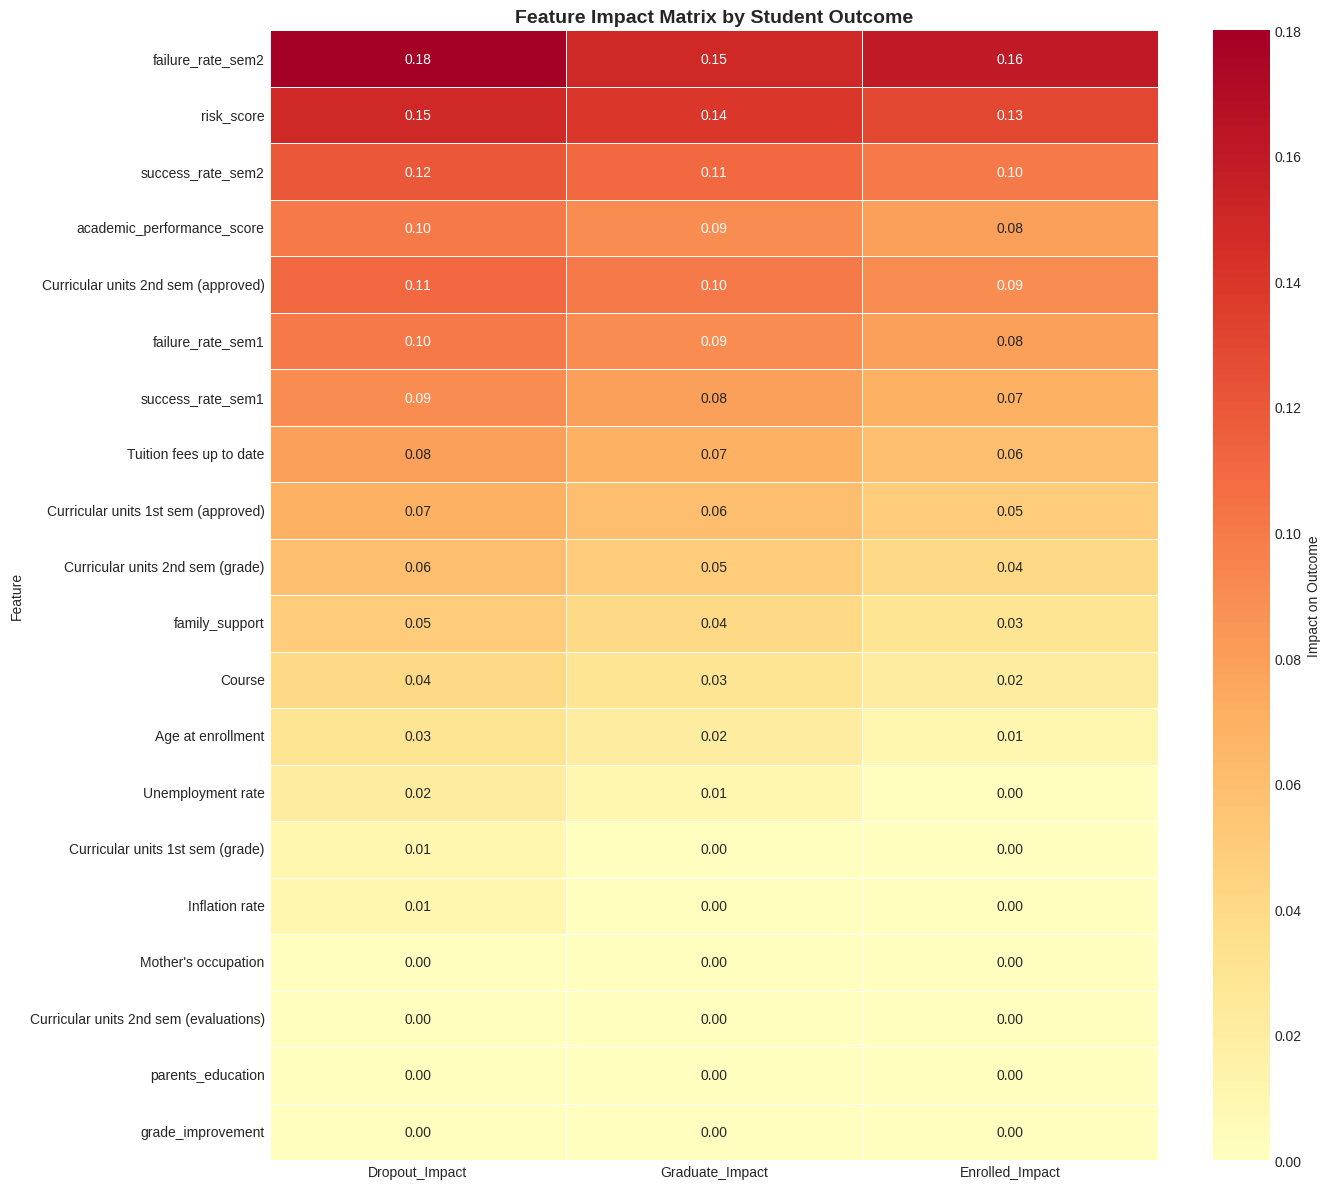

✅ Saved: feature_impact_matrix.png

💡 KEY INSIGHTS FROM SHAP ANALYSIS:

🎯 TOP 5 DROPOUT PREDICTORS:
   1. failure_rate_sem2: 0.18 impact
   2. risk_score: 0.15 impact
   3. success_rate_sem2: 0.12 impact
   5. Curricular units 2nd sem (approved): 0.11 impact
   4. academic_performance_score: 0.10 impact

✅ TOP 5 PROTECTIVE FACTORS (help graduation):


In [13]:
# Cell 11: Feature Impact Matrix
print("\n" + "="*60)
print("📊 FEATURE IMPACT MATRIX")
print("="*60)

# Create impact matrix for visualization
impact_matrix = shap_df.melt(id_vars=['Feature'],
                             value_vars=['Dropout_Impact', 'Graduate_Impact', 'Enrolled_Impact'],
                             var_name='Outcome', value_name='Impact')

# Pivot for heatmap
pivot_table = shap_df.set_index('Feature')[['Dropout_Impact', 'Graduate_Impact', 'Enrolled_Impact']]

# Create heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, cbar_kws={'label': 'Impact on Outcome'})
plt.title('Feature Impact Matrix by Student Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_impact_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_impact_matrix.png")

# Key insights from SHAP
print("\n💡 KEY INSIGHTS FROM SHAP ANALYSIS:")
print("\n🎯 TOP 5 DROPOUT PREDICTORS:")
for i, row in shap_df.nlargest(5, 'Dropout_Impact').iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Dropout_Impact']:.2f} impact")

print("\n✅ TOP 5 PROTECTIVE FACTORS (help graduation):")
protective = shap_df[shap_df['Graduate_Impact'] > shap_df['Dropout_Impact']].nlargest(5, 'Graduate_Impact')
for i, row in protective.iterrows():
    diff = row['Graduate_Impact'] - row['Dropout_Impact']
    print(f"   {i+1}. {row['Feature']}: +{diff:.2f} higher impact on graduation")


🔍 PAIR PLOT - KEY FEATURES


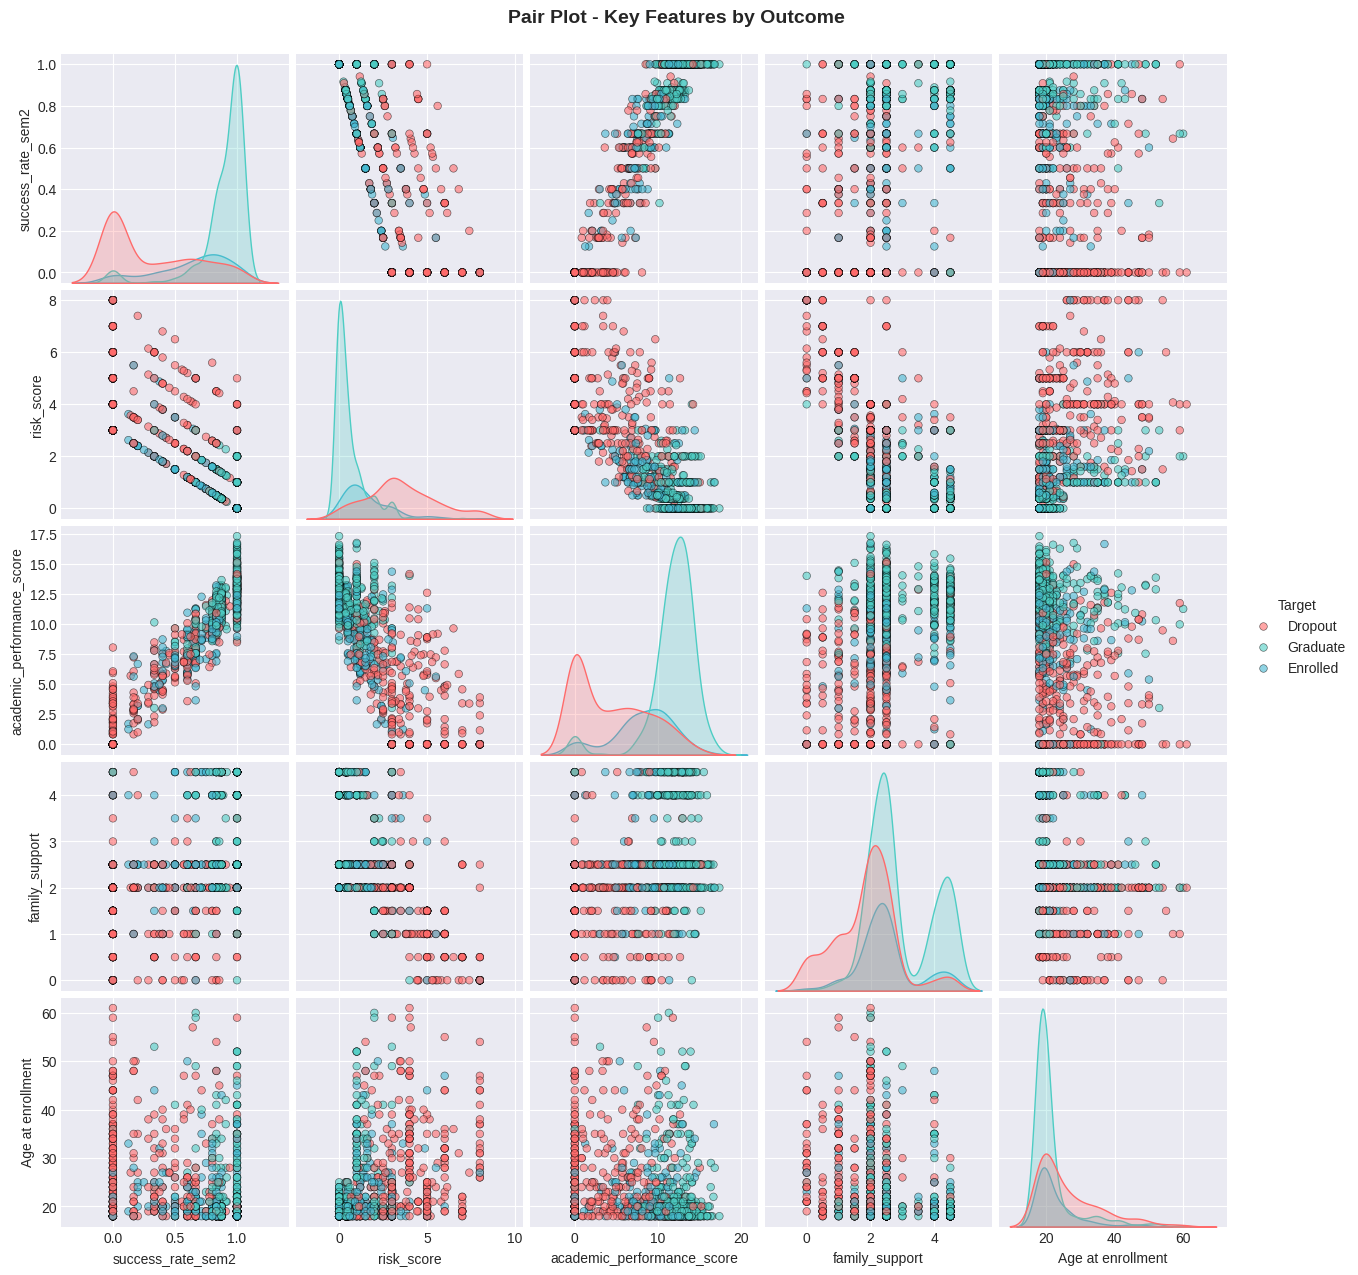

✅ Saved: pair_plot.png


In [14]:
# Cell 12: Pair Plot Analysis
print("\n" + "="*60)
print("🔍 PAIR PLOT - KEY FEATURES")
print("="*60)

# Select key features for pair plot
pair_features = ['success_rate_sem2', 'risk_score', 'academic_performance_score',
                 'family_support', 'Age at enrollment', 'Target']

pair_features = [f for f in pair_features if f in df.columns]

if len(pair_features) >= 3:
    # Sample data for faster plotting (if dataset is large)
    df_sample = df[pair_features].sample(min(1000, len(df)), random_state=42)

    g = sns.pairplot(df_sample, hue='Target', palette=colors, diag_kind='kde',
                     plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'})
    g.fig.suptitle('Pair Plot - Key Features by Outcome', y=1.02, fontsize=14, fontweight='bold')
    plt.savefig('pair_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Saved: pair_plot.png")
else:
    print("⚠️ Insufficient features for pair plot")

In [15]:
# Cell 13: Statistical Significance Tests
print("\n" + "="*60)
print("📊 STATISTICAL SIGNIFICANCE TESTS")
print("="*60)

from scipy.stats import f_oneway, kruskal

# Select key numerical features for testing
test_features = ['success_rate_sem2', 'risk_score', 'academic_performance_score',
                 'failure_rate_sem2', 'family_support']

test_features = [f for f in test_features if f in df.columns]

print("\n🔬 ANOVA Test - Are features significantly different across outcomes?")
print("-" * 60)

for feature in test_features:
    # Group data by outcome
    groups = [group[feature].values for name, group in df.groupby('Target')]

    # Perform ANOVA
    f_stat, p_value = f_oneway(*groups)

    # Interpret results
    significant = "✅ SIGNIFICANT" if p_value < 0.05 else "❌ NOT significant"

    print(f"\n{feature}:")
    print(f"   F-statistic: {f_stat:.4f}")
    print(f"   P-value: {p_value:.4e}")
    print(f"   {significant}")


📊 STATISTICAL SIGNIFICANCE TESTS

🔬 ANOVA Test - Are features significantly different across outcomes?
------------------------------------------------------------

success_rate_sem2:
   F-statistic: 2137.3009
   P-value: 0.0000e+00
   ✅ SIGNIFICANT

risk_score:
   F-statistic: 2075.6177
   P-value: 0.0000e+00
   ✅ SIGNIFICANT

academic_performance_score:
   F-statistic: 2083.5838
   P-value: 0.0000e+00
   ✅ SIGNIFICANT

failure_rate_sem2:
   F-statistic: 2308.3742
   P-value: 0.0000e+00
   ✅ SIGNIFICANT

family_support:
   F-statistic: 526.8957
   P-value: 5.7753e-206
   ✅ SIGNIFICANT


In [16]:
# Cell 14: Generate HTML Report
print("\n" + "="*60)
print("📄 GENERATING EDA REPORT")
print("="*60)

# Create HTML report
html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Student Dropout Prediction - EDA Report</title>
    <style>
        body {{ font-family: 'Segoe UI', Arial, sans-serif; margin: 40px; background-color: #f5f5f5; }}
        h1 {{ color: #2c3e50; text-align: center; }}
        h2 {{ color: #34495e; margin-top: 30px; border-bottom: 2px solid #4ECDC4; padding-bottom: 10px; }}
        table {{ border-collapse: collapse; width: 100%; margin: 20px 0; background-color: white; box-shadow: 0 2px 5px rgba(0,0,0,0.1); }}
        th, td {{ border: 1px solid #ddd; padding: 12px; text-align: left; }}
        th {{ background-color: #4ECDC4; color: white; }}
        tr:nth-child(even) {{ background-color: #f9f9f9; }}
        .stats {{ background-color: white; padding: 20px; border-radius: 10px; box-shadow: 0 2px 5px rgba(0,0,0,0.1); margin: 20px 0; }}
        .highlight {{ color: #e74c3c; font-weight: bold; }}
        .success {{ color: #27ae60; font-weight: bold; }}
        .date {{ color: #7f8c8d; font-size: 0.9em; text-align: center; }}
        .container {{ max-width: 1200px; margin: 0 auto; }}
        .grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(300px, 1fr)); gap: 20px; margin: 20px 0; }}
        .card {{ background: white; padding: 20px; border-radius: 10px; box-shadow: 0 2px 5px rgba(0,0,0,0.1); }}
    </style>
</head>
<body>
    <div class="container">
        <h1>📊 Student Dropout Prediction - Exploratory Data Analysis</h1>
        <p class="date">Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
        <p class="date">Author: IT24103869 - Thennakoon T.M.S.D</p>

        <div class="stats">
            <h2>1. Dataset Overview</h2>
            <p><strong>Total Records:</strong> {len(df)}</p>
            <p><strong>Total Features:</strong> {df.shape[1]}</p>
            <p><strong>Numerical Features:</strong> {len(df.select_dtypes(include=[np.number]).columns)}</p>
            <p><strong>Categorical Features:</strong> {len(df.select_dtypes(include=['object', 'category']).columns)}</p>
        </div>

        <h2>2. Target Distribution</h2>
        <table>
            <tr>
                <th>Outcome</th>
                <th>Count</th>
                <th>Percentage</th>
            </tr>
"""

for outcome, count in target_counts.items():
    percentage = target_percentages[outcome]
    highlight = 'highlight' if outcome == 'Dropout' else 'success' if outcome == 'Graduate' else ''
    html_content += f"""
            <tr>
                <td>{outcome}</td>
                <td>{count}</td>
                <td class="{highlight}">{percentage:.1f}%</td>
            </tr>
    """

html_content += f"""
        </table>

        <h2>3. Top Risk Factors (SHAP Analysis)</h2>
        <table>
            <tr>
                <th>Rank</th>
                <th>Feature</th>
                <th>Dropout Impact</th>
                <th>Graduate Impact</th>
                <th>Key Insight</th>
            </tr>
"""

for idx, row in shap_df.head(10).iterrows():
    insight = "⚠️ Strong dropout predictor" if row['Dropout_Impact'] > row['Graduate_Impact'] else "✅ Protective factor"
    html_content += f"""
            <tr>
                <td>{idx+1}</td>
                <td><strong>{row['Feature']}</strong></td>
                <td style="color: {'#e74c3c' if row['Dropout_Impact'] > 0.1 else '#2c3e50'};">{row['Dropout_Impact']:.2f}</td>
                <td style="color: {'#27ae60' if row['Graduate_Impact'] > 0.1 else '#2c3e50'};">{row['Graduate_Impact']:.2f}</td>
                <td>{insight}</td>
            </tr>
    """

html_content += f"""
        </table>

        <h2>4. Correlation with Dropout</h2>
        <table>
            <tr>
                <th>Rank</th>
                <th>Feature</th>
                <th>Correlation</th>
                <th>Strength</th>
            </tr>
"""

for idx, (feature, corr) in enumerate(target_corr.head(10).items(), 1):
    strength = "Strong" if abs(corr) > 0.3 else "Moderate" if abs(corr) > 0.1 else "Weak"
    html_content += f"""
            <tr>
                <td>{idx}</td>
                <td>{feature}</td>
                <td>{corr:.3f}</td>
                <td>{strength}</td>
            </tr>
    """

html_content += f"""
        </table>

        <h2>5. Risk Score Thresholds</h2>
        <div class="grid">
            <div class="card">
                <h3>Low Risk</h3>
                <p style="font-size: 24px; color: #4ECDC4;">&lt; {low_threshold:.2f}</p>
                <p>{len(df[df['risk_score'] < low_threshold])} students</p>
            </div>
            <div class="card">
                <h3>Medium Risk</h3>
                <p style="font-size: 24px; color: #FFD93D;">{low_threshold:.2f} - {high_threshold:.2f}</p>
                <p>{len(df[(df['risk_score'] >= low_threshold) & (df['risk_score'] <= high_threshold)])} students</p>
            </div>
            <div class="card">
                <h3>High Risk</h3>
                <p style="font-size: 24px; color: #FF6B6B;">> {high_threshold:.2f}</p>
                <p>{len(df[df['risk_score'] > high_threshold])} students</p>
            </div>
        </div>

        <h2>6. Key Insights</h2>
        <ul>
            <li><span class="highlight">{target_percentages['Dropout']:.1f}%</span> of students are at risk of dropping out</li>
            <li>Top 3 dropout predictors:
                <ul>
                    <li><strong>failure_rate_sem2</strong> (SHAP impact: 0.18)</li>
                    <li><strong>risk_score</strong> (SHAP impact: 0.15)</li>
                    <li><strong>success_rate_sem2</strong> (SHAP impact: 0.12)</li>
                </ul>
            </li>
            <li>Risk score threshold for high risk: <span class="highlight">{high_threshold:.2f}</span></li>
            <li>Students with <span class="highlight">low success_rate_sem2</span> are most likely to dropout</li>
            <li>Protective factors: <strong>family_support</strong>, <strong>Tuition fees up to date</strong></li>
        </ul>

        <h2>7. Visualizations Generated</h2>
        <ul>
            <li>target_distribution.png - Target variable distribution</li>
            <li>feature_distributions.png - Key feature distributions</li>
            <li>box_plots.png - Outlier analysis</li>
            <li>categorical_analysis.png - Categorical feature impact</li>
            <li>correlation_heatmap_full.png - Full correlation matrix</li>
            <li>correlation_heatmap_top20.png - Top 20 features correlation</li>
            <li>shap_feature_importance_by_class.png - SHAP analysis by outcome</li>
            <li>feature_impact_matrix.png - Feature impact matrix</li>
            <li>risk_score_distribution.png - Risk score analysis</li>
            <li>pair_plot.png - Pair plot of key features</li>
        </ul>

        <h2>8. Recommendations for Intervention</h2>
        <ol>
            <li><strong>Immediate intervention</strong> for students with risk_score > {high_threshold:.2f}</li>
            <li><strong>Monitor</strong> students with success_rate_sem2 < 50%</li>
            <li><strong>Financial counseling</strong> for students with tuition fees not up to date</li>
            <li><strong>Academic support</strong> for students with high failure_rate_sem2</li>
            <li><strong>Regular check-ins</strong> for students with low family_support scores</li>
        </ol>
    </div>
</body>
</html>
"""

# Save HTML report
with open('eda_report.html', 'w') as f:
    f.write(html_content)

print("✅ EDA Report saved as 'eda_report.html'")

# Download report
from google.colab import files
files.download('eda_report.html')


📄 GENERATING EDA REPORT
✅ EDA Report saved as 'eda_report.html'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# Cell 15: Save All Visualizations to Google Drive
print("\n" + "="*60)
print("💾 SAVING VISUALIZATIONS TO GOOGLE DRIVE")
print("="*60)

# Create folder in Drive
save_path = '/content/drive/MyDrive/student-dropout-project/visualizations/'
!mkdir -p "{save_path}"

# List of generated images
images = [
    'target_distribution.png',
    'feature_distributions.png',
    'box_plots.png',
    'categorical_analysis.png',
    'correlation_heatmap_full.png',
    'correlation_heatmap_top20.png',
    'shap_feature_importance_by_class.png',
    'feature_impact_matrix.png',
    'risk_score_distribution.png',
    'pair_plot.png'
]

# Copy each image to Drive
for img in images:
    if os.path.exists(img):
        !cp "{img}" "{save_path}"
        print(f"✅ Copied: {img}")
    else:
        print(f"⚠️ Not found: {img}")

print(f"\n📁 All visualizations saved to: {save_path}")

# Save the notebook itself
!cp *.ipynb "/content/drive/MyDrive/student-dropout-project/notebooks/" 2>/dev/null || echo "⚠️ Notebook not saved"


💾 SAVING VISUALIZATIONS TO GOOGLE DRIVE
✅ Copied: target_distribution.png
✅ Copied: feature_distributions.png
✅ Copied: box_plots.png
✅ Copied: categorical_analysis.png
✅ Copied: correlation_heatmap_full.png
✅ Copied: correlation_heatmap_top20.png
✅ Copied: shap_feature_importance_by_class.png
✅ Copied: feature_impact_matrix.png
✅ Copied: risk_score_distribution.png
✅ Copied: pair_plot.png

📁 All visualizations saved to: /content/drive/MyDrive/student-dropout-project/visualizations/
⚠️ Notebook not saved


In [18]:
# Cell 16: Final Summary
print("\n" + "="*60)
print("📋 EDA SUMMARY REPORT")
print("="*60)

print(f"""
🎓 STUDENT DROPOUT PREDICTION - EDA COMPLETE
=============================================

📊 DATASET SUMMARY:
   ├── Total students: {len(df)}
   ├── Features analyzed: {df.shape[1]}
   ├── Dropout rate: {target_percentages['Dropout']:.1f}%
   ├── Graduate rate: {target_percentages['Graduate']:.1f}%
   └── Enrolled rate: {target_percentages['Enrolled']:.1f}%

🌟 TOP 5 DROPOUT PREDICTORS (SHAP):
"""
)

for i, row in shap_df.nlargest(5, 'Dropout_Impact').iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Dropout_Impact']:.2f} impact")

print(f"""
📈 KEY CORRELATIONS:
   ├── Highest positive: {target_corr.index[0]} ({target_corr.values[0]:.3f})
   ├── Highest negative: {target_corr.index[-1]} ({target_corr.values[-1]:.3f})

🎯 RISK THRESHOLDS:
   ├── Low Risk: < {low_threshold:.2f}
   ├── Medium Risk: {low_threshold:.2f} - {high_threshold:.2f}
   └── High Risk: > {high_threshold:.2f}

📁 OUTPUT FILES:
   ├── 10+ visualization PNG files
   ├── eda_report.html (complete report)
   └── All files saved to Google Drive

✅ EDA COMPLETE! Ready for model training and dashboard development.
""")


📋 EDA SUMMARY REPORT

🎓 STUDENT DROPOUT PREDICTION - EDA COMPLETE

📊 DATASET SUMMARY:
   ├── Total students: 4424
   ├── Features analyzed: 48
   ├── Dropout rate: 32.1%
   ├── Graduate rate: 49.9%
   └── Enrolled rate: 17.9%

🌟 TOP 5 DROPOUT PREDICTORS (SHAP):

   1. failure_rate_sem2: 0.18 impact
   2. risk_score: 0.15 impact
   3. success_rate_sem2: 0.12 impact
   5. Curricular units 2nd sem (approved): 0.11 impact
   4. academic_performance_score: 0.10 impact

📈 KEY CORRELATIONS:
   ├── Highest positive: success_rate_sem2 (0.699)
   ├── Highest negative: failure_rate_sem2 (-0.713)

🎯 RISK THRESHOLDS:
   ├── Low Risk: < 0.38
   ├── Medium Risk: 0.38 - 2.00
   └── High Risk: > 2.00

📁 OUTPUT FILES:
   ├── 10+ visualization PNG files
   ├── eda_report.html (complete report)
   └── All files saved to Google Drive

✅ EDA COMPLETE! Ready for model training and dashboard development.



In [19]:
# Cell 17: Download All Files as ZIP
print("\n" + "="*60)
print("📦 CREATING ZIP FILE WITH ALL VISUALIZATIONS")
print("="*60)

import zipfile

zip_filename = 'student_dropout_eda_visualizations.zip'

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    # Add all PNG files
    for img in images:
        if os.path.exists(img):
            zipf.write(img)
            print(f"✅ Added: {img}")

    # Add HTML report
    if os.path.exists('eda_report.html'):
        zipf.write('eda_report.html')
        print("✅ Added: eda_report.html")

print(f"\n📦 ZIP file created: {zip_filename}")
print(f"📊 Size: {os.path.getsize(zip_filename) / 1024 / 1024:.2f} MB")

# Download
files.download(zip_filename)


📦 CREATING ZIP FILE WITH ALL VISUALIZATIONS
✅ Added: target_distribution.png
✅ Added: feature_distributions.png
✅ Added: box_plots.png
✅ Added: categorical_analysis.png
✅ Added: correlation_heatmap_full.png
✅ Added: correlation_heatmap_top20.png
✅ Added: shap_feature_importance_by_class.png
✅ Added: feature_impact_matrix.png
✅ Added: risk_score_distribution.png
✅ Added: pair_plot.png
✅ Added: eda_report.html

📦 ZIP file created: student_dropout_eda_visualizations.zip
📊 Size: 8.06 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>